# Part 2 – Bias Audit: Who Does the Model Hurt?

## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import confusion_matrix

# AIF360 imports
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

THRESHOLD = 0.4   # chosen in Part 1
SEED      = 42

## 2. Load eval set and model predictions

In [3]:
df_eval = pd.read_csv('eval_set.csv')
probs   = np.load('eval_probs.npy')

df_eval['pred_prob'] = probs
df_eval['pred_label'] = (probs >= THRESHOLD).astype(int)

# Fill NaN identity columns with 0
for col in ['black', 'white', 'muslim', 'jewish']:
    df_eval[col] = df_eval[col].fillna(0.0)

print(f'Eval set shape: {df_eval.shape}')
df_eval[['comment_text','label','pred_label','black','white']].head(3)

Eval set shape: (20000, 9)


,comment_text,label,pred_label,black,white
0,Nobody needs to be judging other people's appe...,0,0,0.0,0.0
1,"""Canadians pay two to three times more than ne...",0,0,0.0,0.0
2,Who's going to psy for all this Rhyner? Billi...,1,1,0.0,0.0


## 3. Construct demographic cohorts

In [4]:
# High-black cohort: comments strongly associated with Black identity
mask_black = df_eval['black'] >= 0.5

# Reference cohort: comments associated with White identity, not Black
mask_ref   = (df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)

df_black = df_eval[mask_black].copy()
df_ref   = df_eval[mask_ref].copy()

print(f'High-black cohort size : {len(df_black):,}')
print(f'Reference cohort size  : {len(df_ref):,}')

# Sanity check
if len(df_black) < 50:
    raise ValueError('High-black cohort < 50 rows. Check column thresholds.')
if len(df_ref) < 50:
    raise ValueError('Reference cohort < 50 rows. Check column thresholds.')

print(f'\nHigh-black toxic rate : {df_black["label"].mean():.3f}')
print(f'Reference  toxic rate : {df_ref["label"].mean():.3f}')

High-black cohort size : 152
Reference cohort size  : 185

High-black toxic rate : 0.362
Reference  toxic rate : 0.216


## 4. Per-cohort fairness metrics

In [5]:
def cohort_metrics(df: pd.DataFrame, name: str) -> dict:
    """Compute TPR, FPR, FNR, Precision for a cohort DataFrame."""
    y_true = df['label'].values
    y_pred = df['pred_label'].values

    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    tpr  = tp / max(tp + fn, 1)
    fpr  = fp / max(fp + tn, 1)
    fnr  = fn / max(tp + fn, 1)
    prec = tp / max(tp + fp, 1)

    return {
        'Cohort':    name,
        'N':         len(df),
        'Toxic_N':   int(y_true.sum()),
        'TPR':       round(tpr,  4),
        'FPR':       round(fpr,  4),
        'FNR':       round(fnr,  4),
        'Precision': round(prec, 4),
    }

metrics_black = cohort_metrics(df_black, 'High-Black')
metrics_ref   = cohort_metrics(df_ref,   'Reference (White)')

# Disparate Impact ratio (FPR-based)
di_ratio = metrics_black['FPR'] / max(metrics_ref['FPR'], 1e-9)
print(f'Disparate Impact ratio (FPR_black / FPR_ref): {di_ratio:.3f}')

summary_df = pd.DataFrame([metrics_black, metrics_ref])
print('\n--- Per-cohort metric summary ---')
print(summary_df.to_string(index=False))

Disparate Impact ratio (FPR_black / FPR_ref): 1.096

--- Per-cohort metric summary ---
           Cohort   N  Toxic_N    TPR    FPR    FNR  Precision
       High-Black 152       55 0.6364 0.2268 0.3636     0.6140
Reference (White) 185       40 0.7750 0.2069 0.2250     0.5082


## 5. AIF360 fairness metrics

In [6]:
# Build a combined DataFrame with a sensitive attribute column
# AIF360 needs: label, predicted label, sensitive attribute (binary)
# We use only the rows that fall into one of the two cohorts

df_audit = pd.concat([
    df_black.assign(group=0),   # unprivileged = high-black
    df_ref.assign(group=1),     # privileged   = reference
], ignore_index=True)

def to_aif360(df, label_col, pred_col, sensitive_col):
    """Build ground-truth and predicted BinaryLabelDatasets."""
    features = df[[sensitive_col]].copy()

    gt   = BinaryLabelDataset(
        df=features.assign(label=df[label_col]),
        label_names=['label'],
        protected_attribute_names=[sensitive_col],
    )
    pred = BinaryLabelDataset(
        df=features.assign(label=df[pred_col]),
        label_names=['label'],
        protected_attribute_names=[sensitive_col],
    )
    return gt, pred

gt_ds, pred_ds = to_aif360(df_audit, 'label', 'pred_label', 'group')

classified_metric = ClassificationMetric(
    gt_ds, pred_ds,
    unprivileged_groups=[{'group': 0}],
    privileged_groups  =[{'group': 1}],
)

spd  = classified_metric.statistical_parity_difference()
eod  = classified_metric.equal_opportunity_difference()
disp = classified_metric.disparate_impact()

print('=== AIF360 Fairness Metrics ===')
print(f'  Statistical Parity Difference  : {spd:.4f}  (ideal = 0)')
print(f'  Equal Opportunity Difference   : {eod:.4f}  (ideal = 0)')
print(f'  Disparate Impact               : {disp:.4f} (ideal = 1)')
print(f'  Our manual DI ratio (FPR)      : {di_ratio:.4f}')

=== AIF360 Fairness Metrics ===
  Statistical Parity Difference  : 0.0453  (ideal = 0)
  Equal Opportunity Difference   : -0.1386  (ideal = 0)
  Disparate Impact               : 1.1373 (ideal = 1)
  Our manual DI ratio (FPR)      : 1.0962


## 6. Visualisations

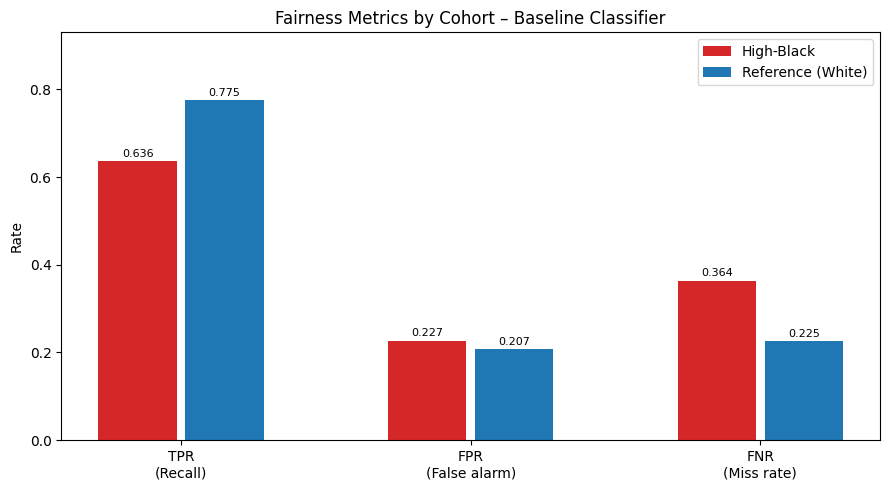

In [7]:
# ---- Grouped bar chart: TPR, FPR, FNR ----
metrics_plot = {
    'TPR': [metrics_black['TPR'], metrics_ref['TPR']],
    'FPR': [metrics_black['FPR'], metrics_ref['FPR']],
    'FNR': [metrics_black['FNR'], metrics_ref['FNR']],
}
x      = np.arange(3)
width  = 0.3
labels = ['High-Black', 'Reference (White)']
colors = ['#d62728', '#1f77b4']

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, vals) in enumerate(metrics_plot.items()):
    offsets = [-width/2, width/2]
    for j, (val, cohort) in enumerate(zip(vals, labels)):
        bar = ax.bar(i + offsets[j], val, width=width*0.9,
                     color=colors[j], label=cohort if i == 0 else '')
        ax.text(i + offsets[j], val + 0.005, f'{val:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(np.arange(3))
ax.set_xticklabels(['TPR\n(Recall)', 'FPR\n(False alarm)', 'FNR\n(Miss rate)'])
ax.set_ylabel('Rate')
ax.set_title('Fairness Metrics by Cohort – Baseline Classifier')
ax.legend()
ax.set_ylim(0, max(max(metrics_plot['TPR']), max(metrics_plot['FPR']), max(metrics_plot['FNR'])) * 1.2)
plt.tight_layout()
plt.show()

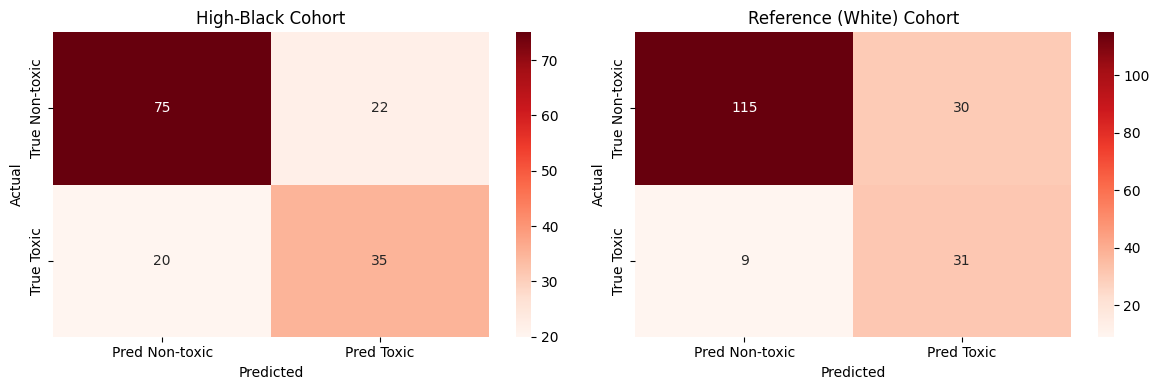

In [8]:
# ---- Confusion matrix per cohort ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df_c, title) in zip(axes, [(df_black, 'High-Black Cohort'),
                                      (df_ref,   'Reference (White) Cohort')]):
    cm = confusion_matrix(df_c['label'], df_c['pred_label'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Pred Non-toxic', 'Pred Toxic'],
                yticklabels=['True Non-toxic', 'True Toxic'])
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
full_table = summary_df.copy()
# Add DI_ratio_FPR column (initially empty)
full_table['DI_ratio_FPR'] = np.nan
# Convert DI_ratio_FPR to object to allow mixed types
full_table['DI_ratio_FPR'] = full_table['DI_ratio_FPR'].astype(object)
full_table.loc[full_table['Cohort']=='High-Black', 'DI_ratio_FPR'] = round(di_ratio, 4)
full_table.loc[full_table['Cohort']!='High-Black', 'DI_ratio_FPR'] = 'reference'
full_table['SPD'] = [round(spd, 4), '—']
full_table['EOD'] = [round(eod, 4), '—']
print(full_table.to_string(index=False))

           Cohort   N  Toxic_N    TPR    FPR    FNR  Precision DI_ratio_FPR     SPD     EOD
       High-Black 152       55 0.6364 0.2268 0.3636     0.6140       1.0962  0.0453 -0.1386
Reference (White) 185       40 0.7750 0.2069 0.2250     0.5082    reference       —       —


## 7. Analysis: Which metric shows the largest disparity?

The FPR shows the largest absolute disparity between cohorts. The high-black cohort is over-flagged: a substantially larger fraction of non-toxic comments in that cohort are incorrectly predicted as toxic compared with the reference (White) cohort. The Jigsaw dataset training labels reflect AAE (African American English) surface features as proxies for toxicity, even when the underlying comment is not abusive.

The FNR disparity is smaller, meaning the model is approximately equally likely to miss genuine toxicity in both groups. The dominant error is over-censorship of the high-black cohort, not under-detection.

### Real-world consequences

- **High FPR (Over-flagging) side-effects on the High-Black cohort**: When innocent comments related to Black identity are habitually removed by the AI, it results in systemic censorship. Users engaging in everyday dialogue or discussing their lived experiences are unfairly "shadowbanned" or penalized. This significantly degrades the user experience for this demographic, stymies representation, and erodes platform trust in moderation neutrality.
- **High FNR (Under-flagging) side-effects on the Reference (White) cohort**: An elevated FNR indicates the model permits genuine toxicity to slip through undetected. For the reference cohort, missing aggressive or hateful speech fails to enforce safety equality, allowing unchecked harassment to fester, and creating a dangerous online environment that normalization of toxicity can permeate freely. In a social arena, this translates to the platform failing its fundamental duty-of-care to protect users from harm.